# Introduction to real-time time-dependent Hartree-Fock theory

This notebook is written for graduate students who already understand the
**two-level system (TLS)** and want to make the conceptual jump to
**real-time mean-field electronic dynamics** in molecules.

We take $\rm{H}_2$, the smallest closed-shell molecule, as an example.


## 0. Roadmap: from a two-level system to many-electron mean field

Recall the canonical TLS:

$$H_0 = \tfrac{1}{2}\,\omega_0\,\sigma_z, \qquad
\hat{\mu} = \mu_0\,\sigma_x, \qquad
i\,\dot{\rho} = [H_0,\rho].$$

A weak delta kick along the dipole, $U_{\text{kick}} = e^{\,i\kappa\hat\mu}$,
prepares a small coherence between the two eigenstates. The induced dipole
then oscillates,

$$\Delta\mu(t) \propto \sin(\omega_0\, t),$$

and its FFT yields a single peak at $\omega = \omega_0$.

Real-time time-dependent Hartree–Fock (RT-TDHF) applies the same idea to a
many-electron system.

Below is the comparison between TLS dynamics and RT-TDHF:

| concept                | TLS                              | RT-TDHF                                                       |
|------------------------|----------------------------------|---------------------------------------------------------------|
| state                  | $\rho$ ($2\times 2$)            | density matrix $P$ in the AO basis ($N\times N$)              |
| Hamiltonian            | $H_0$ (constant)                 | Fock $F[P] = H_{\text{core}}+J[P]-\tfrac12 K[P]$ (depends on $P$!) |
| equation of motion     | $i\dot\rho=[H_0,\rho]$         | $i\dot P=[F[P],P]$ (Liouville–von Neumann, **nonlinear**)  |
| dipole operator        | $\mu_0\sigma_x$                 | AO matrix $\boldsymbol\mu = -\mathbf r$ (electronic) + nuclei |
| eigenbasis             | $\sigma_z$ basis                 |  orthogonal AO basis using $X = S^{-1/2}$ transform                  |
| linear-response peaks  | one, at $\omega_0$              | many, such as bonding→antibonding ($\sigma\to\sigma^*$). |

The *only* non-trivial twist is the second row: in mean-field electronic
theory, the effective Hamiltonian $F[P]$ depends on the state $P$ itself.
In Hartree-Fock theory,
as electrons feel the average potential of all other electrons, the Hamiltonian
becomes **nonlinear**, which makes it difficult to maintain the stability of
numerical propagation as a function of time. 


## 1. Recall the TLS dynamics

Before moving to $\rm{H}_2$, let us run the time-resolved dynamics for a single TLS.


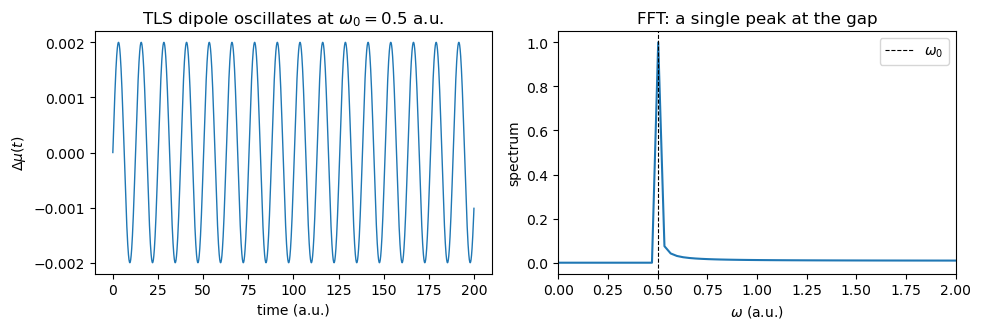

In [1]:
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

omega0    = 0.5      # TLS gap (a.u.)
mu0       = 1.0      # transition dipole (a.u.)
kappa_tls = 1.0e-3   # weak kick
dt_tls    = 0.05
nstep_tls = 4000

# 1. Hamiltonian and dipole operator
H0 = 0.5 * omega0 * np.array([[ 1, 0], [ 0,-1]], dtype=complex)   # sigma_z
mu_op = mu0       * np.array([[ 0, 1], [ 1, 0]], dtype=complex)   # sigma_x

# 2. Ground state density: |1><1| (lower eigenstate of sigma_z)
rho = np.array([[0, 0], [0, 1]], dtype=complex)

# 3. Delta kick: rho -> exp(+i kappa mu) rho exp(-i kappa mu)
U_kick = expm(1j * kappa_tls * mu_op)
rho = U_kick @ rho @ U_kick.conj().T

# 4. Field-free unitary propagation: rho -> exp(-i H0 dt) rho exp(+i H0 dt)
U_dt = expm(-1j * dt_tls * H0)
times_tls, dip_tls = [0.0], [np.trace(mu_op @ rho).real]
for n in range(1, nstep_tls + 1):
    rho = U_dt @ rho @ U_dt.conj().T
    times_tls.append(n * dt_tls)
    dip_tls.append(np.trace(mu_op @ rho).real)
times_tls = np.array(times_tls)
dip_tls   = np.array(dip_tls) - dip_tls[0]

# 5. FFT of the induced dipole
sig_tls = dip_tls * np.exp(-1e-3 * times_tls)
fft_tls = np.fft.rfft(sig_tls)
omega_tls = 2.0 * np.pi * np.fft.rfftfreq(sig_tls.size, d=dt_tls)
spec_tls  = -omega_tls * fft_tls.imag
spec_tls  = np.clip(spec_tls / (np.abs(spec_tls).max() + 1e-30), 0.0, None)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(times_tls, dip_tls, lw=1)
ax[0].set(xlabel="time (a.u.)", ylabel=r"$\Delta\mu(t)$",
          title=fr"TLS dipole oscillates at $\omega_0={omega0}$ a.u.")
ax[1].plot(omega_tls, spec_tls, lw=1.5)
ax[1].axvline(omega0, color="k", ls="--", lw=0.8, label=r"$\omega_0$")
ax[1].set(xlim=(0, 2), xlabel=r"$\omega$ (a.u.)", ylabel="spectrum",
          title="FFT: a single peak at the gap"); ax[1].legend()
plt.tight_layout(); plt.show()


## 2. The same procedure for $\rm{H}_2$

Below are the equations we will implement. Compare each line with the TLS
dynamics just above.

**Closed-shell Fock matrix** (the analog of $H_0$, but state-dependent):

$$F[P] = H_{\text{core}} + J[P] - \tfrac12 K[P], \qquad
J_{\mu\nu}=\sum_{\rho\sigma}(\mu\nu|\rho\sigma)P_{\rho\sigma}, \quad
K_{\mu\nu}=\sum_{\rho\sigma}(\mu\rho|\nu\sigma)P_{\rho\sigma}.$$

**Symmetric orthogonalization** (going to a clean "basis", because
atomic orbitals, or AOs, are not orthogonal):

$$X = S^{-1/2}, \qquad U = S^{1/2}, \qquad
P_{\text{orth}}=U\,P\,U^\top, \qquad
F_{\text{orth}}=X^\top F X.$$

**Delta kick** (identical operator structure as in the TLS):

$$P_{\text{orth}}(0^+) = e^{\,i\kappa\,\mu_{z,\text{orth}}}\,
P_{\text{orth}}(0^-)\, e^{-i\kappa\,\mu_{z,\text{orth}}}.$$

**Unitary propagation in the orthogonal basis** (TLS analog: $e^{-iH_0\Delta t}$):

$$P(t+\Delta t)\approx
e^{-i\Delta t\, F[P(t)]}\,P(t)\,e^{+i\Delta t\, F[P(t)]}.$$

**Spectrum** (identical formula to the TLS):

$$\alpha_{zz}(\omega)\approx \frac{\Delta t}{\kappa}\,
\text{FFT}\!\big[\Delta\mu_z(t)\,e^{-\eta t}\big], \qquad
S(\omega)\propto\omega\,\text{Im}\,\alpha_{zz}(\omega).$$

The single new ingredient compared to the TLS is that **$F$ is rebuilt
from $P$ at every step**.


In [2]:
import numpy as np
import psi4
import matplotlib.pyplot as plt
from scipy.linalg import expm, fractional_matrix_power

# Unit conversions
au_to_fs = 0.024188843265857
hartree_to_ev = 27.211386245988

# Simulation parameters
R_angstrom = 0.74        # H-H bond length
dt = 0.04                # time step in atomic units
nsteps = 1200            # total number of propagation steps
kappa = 1.0e-3           # delta-kick strength (a.u.)
eta = 1.0e-3             # optional exponential damping for FFT (a.u.^-1)

# Make plots a bit larger
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["font.size"] = 12

## 3. Step 1 - Ground state: solve RHF to get $P_0$

In the TLS we picked the ground state $|1\rangle\langle 1|$ by hand. For
a real molecule we have to *solve* the static problem first: a
self-consistent diagonalization of $F[P]$, i.e. ordinary RHF.

We place $\rm{H}_2$ along the $z$ axis with the bond midpoint at the origin so
that the permanent dipole is zero by symmetry.


In [3]:
psi4.core.clean()
psi4.set_memory("1 GB")
psi4.core.set_num_threads(1)
psi4.core.set_output_file("psi4_h2_rt_tdhf.out", False)

mol = psi4.geometry(f'''
units angstrom
nocom
noreorient
symmetry c1
0 1
H 0.0 0.0 {-R_angstrom/2.0}
H 0.0 0.0 {+R_angstrom/2.0}
''')

psi4.set_options({
    "basis": "cc-pvdz",
    "reference": "rhf",
    "scf_type": "pk",
    "e_convergence": 1e-12,
    "d_convergence": 1e-12,
})

E_scf, wfn = psi4.energy("scf", return_wfn=True)
print(f"Ground-state RHF energy = {E_scf:.12f} Eh")


  Memory set to 953.674 MiB by Python driver.
  Threads set to 1 by Python driver.
Ground-state RHF energy = -1.128700093561 Eh


## 4. Step 2 - Build $F$, $\boldsymbol\mu$, and the orthogonalizer

The "Hamiltonian" of an electronic problem in a finite AO basis is the
Fock matrix $F[P]$. Building it requires:

- the **overlap** $S$ (because AOs are not orthogonal),
- the **core Hamiltonian** $H_{\text{core}}$ (kinetic + electron–nucleus),
- the **two-electron integrals** $(\mu\nu|\rho\sigma)$, from which $J[P]$
  and $K[P]$ are contracted at every step,
- the **dipole integrals**, which become the AO matrix of $\hat\mu$.

We then build $X=S^{-1/2}$ once. Multiplying by $X$ on both sides plays
the same role as moving a TLS Hamiltonian into the basis where $\sigma_z$
is diagonal: in that basis the propagator has the simple form
$P\to e^{-iF\Delta t}\,P\,e^{+iF\Delta t}$.


In [4]:
mints = psi4.core.MintsHelper(wfn.basisset())

S = np.asarray(wfn.S())
Hcore = np.asarray(wfn.H())
ERI = np.asarray(mints.ao_eri())

# Psi4 returns position integrals <chi_mu | x,y,z | chi_nu>.
# The electronic dipole operator is -r, so we add the minus sign here.
x_ao, y_ao, z_ao = [np.asarray(m) for m in mints.ao_dipole()]
mu_x_ao = -x_ao
mu_y_ao = -y_ao
mu_z_ao = -z_ao

# Closed-shell total density P = 2 * D_alpha (density matrix of the alpha electron)
P0 = 2.0 * np.asarray(wfn.Da())

# Symmetric orthogonalization matrices
X = fractional_matrix_power(S, -0.5)
U = fractional_matrix_power(S,  0.5)

# Nuclear dipole (in a.u.); for midpoint-centered H2 this is zero
R_bohr = np.array([[mol.x(A), mol.y(A), mol.z(A)] for A in range(mol.natom())])
Z = np.array([mol.Z(A) for A in range(mol.natom())])
mu_nuc = (Z[:, None] * R_bohr).sum(axis=0)

print("Number of AO functions =", S.shape[0])
print("Ground-state total dipole (a.u.) =", np.trace(P0 @ mu_z_ao).real + mu_nuc[2])

Number of AO functions = 10
Ground-state total dipole (a.u.) = 3.497202527569243e-15


### Inspect the orbital structure: the closest analog of $\omega_0$

The bare HOMO–LUMO gap is the simplest analog of the TLS gap $\omega_0$.
But the actual RT-TDHF (and LR-TDHF) excitation energy is shifted from
this gap by the electron–electron interaction in $J[P]-\tfrac12K[P]$.


In [5]:
eps = np.asarray(wfn.epsilon_a())
nocc = wfn.nalpha()  # number of doubly-occupied MOs (= 1 for H2)

print(f"All MO energies (Eh):")
for i, e in enumerate(eps):
    label = "HOMO" if i == nocc - 1 else "LUMO" if i == nocc else "    "
    print(f"  MO {i:2d}  {label}  e = {e: .5f} Eh")

gap = eps[nocc] - eps[nocc - 1]
print(f"\nHOMO–LUMO gap = {gap:.4f} Eh = {gap*hartree_to_ev:.3f} eV")
print("\nWe will see below that the lowest RT-TDHF / LR-TDHF peak is *not*")
print("at this bare gap. Instead, it is shifted by electron-electron interactions,")
print("which is precisely the nonlinear part of F[P].")


All MO energies (Eh):
  MO  0  HOMO  e = -0.59241 Eh
  MO  1  LUMO  e =  0.19744 Eh
  MO  2        e =  0.47932 Eh
  MO  3        e =  0.93732 Eh
  MO  4        e =  1.29290 Eh
  MO  5        e =  1.29290 Eh
  MO  6        e =  1.95702 Eh
  MO  7        e =  2.04352 Eh
  MO  8        e =  2.04352 Eh
  MO  9        e =  3.61047 Eh

HOMO–LUMO gap = 0.7899 Eh = 21.493 eV

We will see below that the lowest RT-TDHF / LR-TDHF peak is *not*
at this bare gap. Instead, it is shifted by electron-electron interactions,
which is precisely the nonlinear part of F[P].


In [6]:
def build_fock(P):
    """Closed-shell RHF Fock matrix built from the total AO density P."""
    J = np.einsum("pqrs,rs->pq", ERI, P, optimize=True)
    K = np.einsum("prqs,rs->pq", ERI, P, optimize=True)
    F = Hcore + J - 0.5 * K
    return 0.5 * (F + F.conj().T)


def ao_to_orth_density(P):
    return U @ P @ U.conj().T


def orth_to_ao_density(P_orth):
    return X @ P_orth @ X.conj().T


def ao_to_orth_operator(A):
    return X.conj().T @ A @ X


def dipole_z(P):
    """Total molecular dipole along z (electrons + nuclei)."""
    return np.trace(P @ mu_z_ao).real + mu_nuc[2]


def rhf_energy(P, F):
    """Closed-shell RHF total energy from the total density P."""
    return 0.5 * np.trace(P @ (Hcore + F)).real + mol.nuclear_repulsion_energy()

## 5. Step 3 - Kick the molecule (same operator as in the TLS)

In the TLS we applied $e^{i\kappa\sigma_x}$ to the ground state. Here we
apply $e^{i\kappa\hat\mu_z}$ to the orthogonalized density, which
generates a small coherence between every occupied MO and every virtual
MO with non-zero $z$-dipole matrix element to it (in $\rm{H}_2$, the dominant
channel is $\sigma_g \to \sigma_u^*$).

Because $\kappa$ is small, we stay in the linear-response regime: the Fourier
transform of $\Delta\mu_z(t)$ samples the linear-response polarizability
$\alpha_{zz}(\omega)$. 


In [7]:
P0_orth = ao_to_orth_density(P0)
mu_z_orth = ao_to_orth_operator(mu_z_ao)

U_kick = expm(1j * kappa * mu_z_orth)
P_kicked_orth = U_kick @ P0_orth @ U_kick.conj().T
P_kicked = orth_to_ao_density(P_kicked_orth)
P_kicked = 0.5 * (P_kicked + P_kicked.conj().T)

print(f"Induced dipole immediately after the kick = {dipole_z(P_kicked): .6e} a.u.")

Induced dipole immediately after the kick =  3.941292e-15 a.u.


## 6. Step 4 - Real-time propagation

We use the simplest possible scheme: at each step, build $F$ from the
current $P$, then take a unitary step

$$P(t+\Delta t) = e^{-i\Delta t\, F[P(t)]}\,P(t)\,e^{+i\Delta t\, F[P(t)]}.$$

This is **first-order accurate** because $F$ is evaluated at the start of
the step. In other words, the energy drift 
following this unitary propagation scheme scales in the order of $\Delta t$.

For improving the energy conservation, a midpoint or modified-midpoint scheme (the "MMUT" propagator
used in production codes) can be applied, but this is outside the scope of this tutorial.


In [8]:
import numpy as np
from scipy.linalg import expm

def propagate_naive_unitary(P_start_orth, dt, nsteps):
    """Naive first-order RT-TDHF propagation in the orthonormal basis.

    Propagation rule:
        F_n = F[P_n]
        U_n = exp(-i dt F_n)
        P_{n+1} = U_n P_n U_n^dagger

    This is simpler than MMUT because it does not use a midpoint density or
    half-step bootstrap. It is unitary, but only first-order accurate in time
    for nonlinear TDHF.
    """

    # Initial density
    P_orth = P_start_orth.copy()
    P_orth = 0.5 * (P_orth + P_orth.conj().T)

    # Initial AO density and observables
    P_ao = orth_to_ao_density(P_orth)
    P_ao = 0.5 * (P_ao + P_ao.conj().T)

    F_ao = build_fock(P_ao)
    F_ao = 0.5 * (F_ao + F_ao.conj().T)

    times = [0.0]
    dipoles = [dipole_z(P_ao)]
    energies = [rhf_energy(P_ao, F_ao)]

    for step in range(1, nsteps + 1):
        # Fock from the density at the beginning of the step
        P_ao = orth_to_ao_density(P_orth)
        P_ao = 0.5 * (P_ao + P_ao.conj().T)

        F_ao = build_fock(P_ao)
        F_ao = 0.5 * (F_ao + F_ao.conj().T)

        F_orth = ao_to_orth_operator(F_ao)
        F_orth = 0.5 * (F_orth + F_orth.conj().T)

        # Naive full-step unitary propagation
        U_step = expm(-1j * dt * F_orth)
        P_orth = U_step @ P_orth @ U_step.conj().T
        P_orth = 0.5 * (P_orth + P_orth.conj().T)

        # Back to AO basis for analysis
        P_ao = orth_to_ao_density(P_orth)
        P_ao = 0.5 * (P_ao + P_ao.conj().T)

        F_ao = build_fock(P_ao)
        F_ao = 0.5 * (F_ao + F_ao.conj().T)

        times.append(step * dt)
        dipoles.append(dipole_z(P_ao))
        energies.append(rhf_energy(P_ao, F_ao))

    return np.array(times), np.array(dipoles), np.array(energies)

In [9]:
times_au, dipoles_z, energies = propagate_naive_unitary(P_kicked_orth, dt, nsteps)
times_fs = times_au * au_to_fs

print(f"Total propagation time = {times_fs[-1]:.3f} fs")
print(f"Max energy drift       = {np.max(np.abs(energies - energies[0])):.3e} Eh")

Total propagation time = 1.161 fs
Max energy drift       = 3.190e-07 Eh


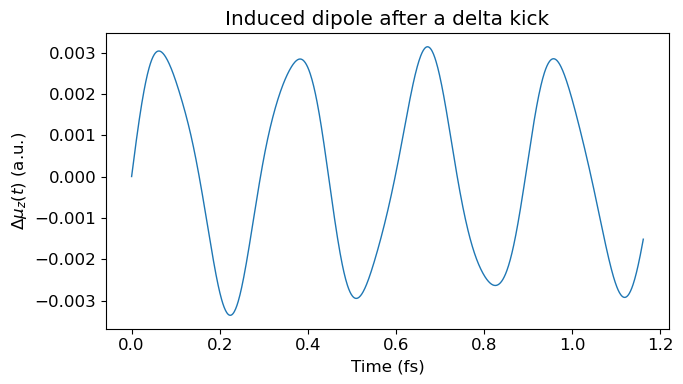

In [10]:
delta_mu = dipoles_z - dipoles_z[0]

plt.plot(times_fs, delta_mu, lw=1.0)
plt.xlabel("Time (fs)")
plt.ylabel(r"$\Delta \mu_z(t)$ (a.u.)")
plt.title("Induced dipole after a delta kick")
plt.tight_layout()
plt.show()

Here, just like the TLS dynamics, $\Delta\mu_z(t)$ is a
small oscillation around zero. However, unlike the TLS, it is **not** a single
sinusoid: it is a sum of contributions from every dipole-allowed
excitation that the kick excited.


## 7. Step 5 - Spectrum from the dipole trajectory

The FFT step is identical to the TLS procedure. The damping factor
$e^{-\eta t}$ below broadens the discrete peaks into Lorentzians.

The absorption-like spectrum is

$$\alpha_{zz}(\omega) \approx \frac{\Delta t}{\kappa}\,
\text{FFT}\!\big[\Delta\mu_z(t)\,e^{-\eta t}\big], \qquad
S(\omega)\propto \omega\,\text{Im}\,\alpha_{zz}(\omega).$$

The factor of $\omega$ is the standard convention that turns the
polarizability into an oscillator-strength-like quantity.


In [11]:
signal = delta_mu * np.exp(-eta * times_au)

fft_vals = np.fft.rfft(signal)
omega_au = 2.0 * np.pi * np.fft.rfftfreq(signal.size, d=dt)
energy_ev = omega_au * hartree_to_ev

# A simple absorption-like spectrum from the NumPy FFT.
alpha_w = (dt / kappa) * fft_vals
spectrum = omega_au * (-alpha_w.imag)

# Clean up the zero-frequency point and any tiny negative noise
spectrum[0] = 0.0
spectrum = np.clip(spectrum, 0.0, None)

# Normalize for plotting
if spectrum.max() > 0:
    spectrum = spectrum / spectrum.max()

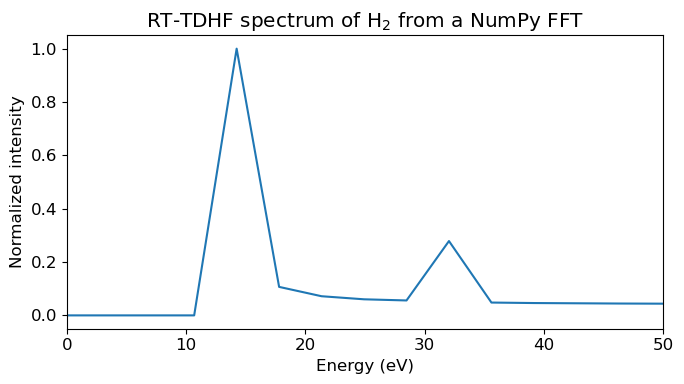

In [12]:
plt.plot(energy_ev, spectrum, lw=1.5)
plt.xlim(0, 50)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized intensity")
plt.title("RT-TDHF spectrum of H$_2$ from a NumPy FFT")
plt.tight_layout()
plt.show()

## 8. Cross-check: linear response TDHF (LR-TDHF)

LR-TDHF solves an eigenvalue problem for the linear response of the same
Fock operator. In the **weak-kick limit**, RT-TDHF and LR-TDHF must
predict the same excitation energies and oscillator strengths. The peak
positions in our spectrum should line up with the LR-TDHF stick spectrum.


LR-TDHF excitation energy (eV): [13.91137134 21.31926952 32.05653779]
LR-TDHF oscillator strength: [0.53262017 0.         0.13572863]


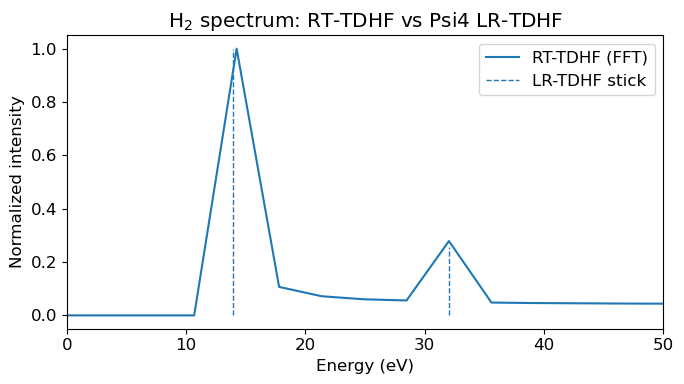

In [13]:
from psi4.driver.procrouting.response.scf_response import tdscf_excitations

psi4.set_options({
    "basis": "cc-pvdz",
    "reference": "rhf",
    "scf_type": "pk",
    "save_jk": True,
})

E_lr, wfn_lr = psi4.energy("scf", return_wfn=True, molecule=mol)
lr_res = tdscf_excitations(wfn_lr, states=3, tda=False)

exc_ev = np.array([r["EXCITATION ENERGY"] for r in lr_res]) * hartree_to_ev
osc = np.array([r["OSCILLATOR STRENGTH (LEN)"] for r in lr_res])

print("LR-TDHF excitation energy (eV):", exc_ev)
print("LR-TDHF oscillator strength:", osc)

plt.plot(energy_ev, spectrum, label="RT-TDHF (FFT)")
plt.vlines(exc_ev, 0, osc/np.max(osc), linestyles="dashed", linewidth=1.0, label="LR-TDHF stick")
plt.xlim(0, 50)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized intensity")
plt.title("H$_2$ spectrum: RT-TDHF vs Psi4 LR-TDHF")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Padé FFT in MaxwellLink: a shorter trajectory suffices

A plain FFT needs a long trajectory to resolve sharp peaks: the spectral
resolution is $\Delta\omega \sim 2\pi / T_{\text{total}}$. The Padé
approximant rewrites the FFT as a rational function and converges much
faster, so you can extract clean peaks from a *shorter* trajectory at
the cost of slightly biased line shapes. This Padé function is shipped within 
MaxwellLink.


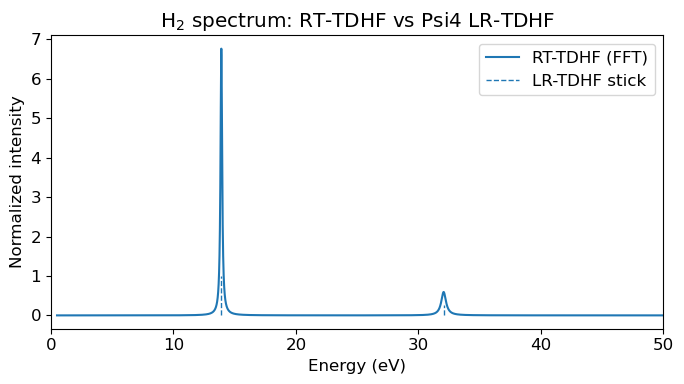

In [14]:
from maxwelllink.tools import rt_tddft_spectrum

# call Pade approximation FFT spectrum function
freq_ev, sp_tot, t_fs, mu = rt_tddft_spectrum(delta_mu, dt, e_cutoff_ev=50)

plt.plot(freq_ev, sp_tot, label="RT-TDHF (FFT)")
plt.vlines(exc_ev, 0, osc/np.max(osc), linestyles="dashed", linewidth=1.0, label="LR-TDHF stick")
plt.xlim(0, 50)
plt.xlabel("Energy (eV)")
plt.ylabel("Normalized intensity")
plt.title("H$_2$ spectrum: RT-TDHF vs Psi4 LR-TDHF")
plt.legend()
plt.tight_layout()
plt.show()